# 1. Quais são as tendências de vendas ao longo do tempo?
    - Como as vendas variam ao longo dos meses e anos?
    - Existem sazonalidades que podem ser exploradas para campanhas de marketing?
# 2. Qual é o perfil dos clientes?
    - Qual é a distribuição de idades dos cleintes?
    - Como as vendas variam entre diferentes grupos etários e gêneros?
# 3. Quais são os produtos mais vendidos?
    - Quais categorias e subcategorias de produtos são mais populares?
    - Como a demanda por diferentes produtos varias ao longo do tempo?
# 4. Análise Geográfica
    - Quais são os principais mercados (países e estados) em termos de vendas?
    - Existe potêncial para expansão em regiões repecíficas?
# 5. Análise de Margem de Lucro
    - Quais produtos ou categorias têm a maior margem de lucro?
    - Como otimizar o mix de produtos para maximizar a lucratividade?
# 6. Comportamento de Compra dos Clientes
    - Qual é  a frequência de compra dos clientes?
    - Existem clientes recorrentes e qual é o seu impacto nas vendas totais?
# 7. Eficiência de Custos
    - Qual é a relação entre o custo unitário e o preço unitário dos produtos?
    - Existem oportunidades para reduzir os custos e aumentar a margem de lucro?

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("Sales.csv")
df.info() #DataFrame não possui valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [4]:
#Colocando todos as colunas para letras minusculas
df.columns = [x.lower() for x in df.columns]
#Colocando a coluna date para datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              113036 non-null  datetime64[ns]
 1   day               113036 non-null  int64         
 2   month             113036 non-null  object        
 3   year              113036 non-null  int64         
 4   customer_age      113036 non-null  int64         
 5   age_group         113036 non-null  object        
 6   customer_gender   113036 non-null  object        
 7   country           113036 non-null  object        
 8   state             113036 non-null  object        
 9   product_category  113036 non-null  object        
 10  sub_category      113036 non-null  object        
 11  product           113036 non-null  object        
 12  order_quantity    113036 non-null  int64         
 13  unit_cost         113036 non-null  int64         
 14  unit

In [6]:
# 1) Quantidade total de vendas cada dia.
qtdd_total = df.groupby("date")[["order_quantity"]].sum() #Poderia tirar essa lista de listas para utilizar sem o squeeze()

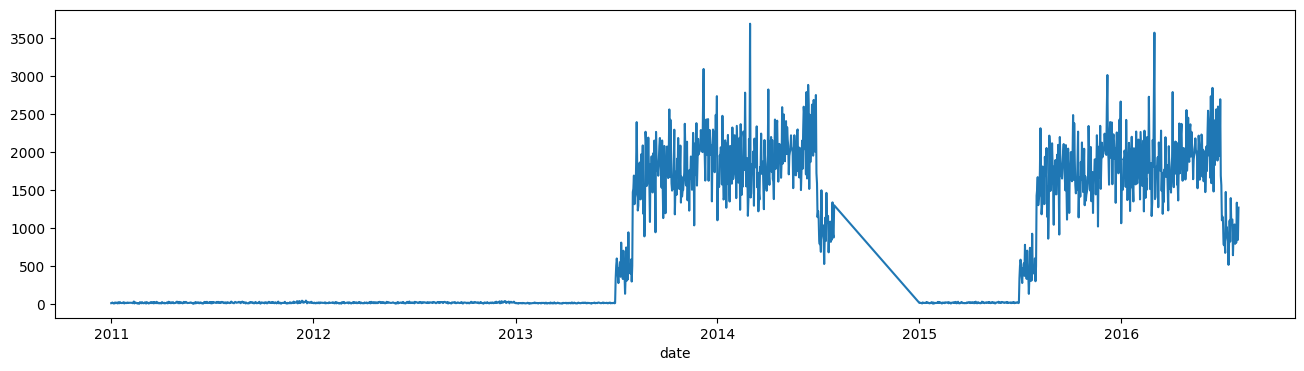

In [7]:
# Visualizar em termos de um gráfico para melhorar a visualizaçao em uma serie temporal
plt.figure(figsize=(16,4)) # Aumentar o gráfico
sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze()) #squeeze() - Deixa o array em forma unidimensional
plt.show()

Em meados de 2013 as vendas começaram a explodir, temos uma tendencia clara de alta até meados de 2014, em que as vendas caíram novamente até meados de 2015 que as vendas voltaram!
Como a escala grande de 5 anos tivemos muito mais vendas em alguns anos que outros, isso faz com que a escala do eixo y seja afetada e quase nao conseguimos enxergar a dinamica de vendas nos anos iniciais.
* Isso é um bom motivo para visualizar ano a ano

In [8]:
qtdd_total

,order_quantity
date,
2011-01-01,8
2011-01-02,9
2011-01-03,17
2011-01-04,10
2011-01-05,5
...,...
2016-07-27,807
2016-07-28,1332
2016-07-29,895


Para evitar oscilações muito grande: Aplica uma determinada janela de tempo e agrega as informações dentro dessa janela com a funçao de agregaçao mean()
* Deixar ela mais "suave"
* Quanto maior a quantidade de dias, maior a janela, mais suave

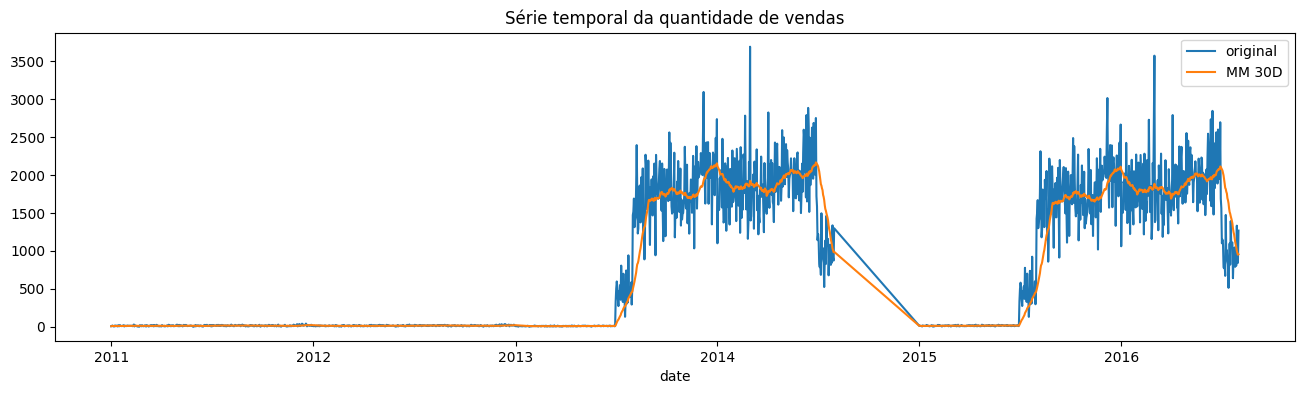

In [9]:
# Rolling - O indice precisa ser datetime para ele funcionar de maneira simples.
qtdd_total_30d = qtdd_total.rolling(window = "30D").mean()
qtdd_total_3d = qtdd_total.rolling(window = "3D").mean() #Criar uma janela de 3 dias e ir deslizando ela pelos dados e calculando a media desses valores e colocando dentro de cada celula 

plt.figure(figsize=(16,4))
plt.title("Série temporal da quantidade de vendas")

sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze(), label = "original")
#sns.lineplot(x = qtdd_total_3d.index, y = qtdd_total_3d.values.squeeze(), label = "MM 3D")
sns.lineplot(x = qtdd_total_30d.index, y = qtdd_total_30d.values.squeeze(), label = "MM 30D")

plt.show()

* Com a janela de 3 dias não fica uma visualizaçao muito boa
* Com a janela de 30 dias é possível observar de maneira muito mais clara como ficou essa oscilação esse padrão de vendas que subiu mes a mes, enxergar melhor as tendencias integrando todo o ruido.
* Fica evidente que o periodo de julho de 2013 até julho de 2014 é muito parecido com julho de 2015 até julho de 2016.
* Podem ser dados "criados" apenas copiados

Mas ainda não é possivel visualizar a evolução de vendas nos primeiros 2 anos e meio, por isso irei visualizar essa série ano a ano.

In [10]:
for ano in df["year"].sort_values().unique():
    print(ano)

2011
2012
2013
2014
2015
2016


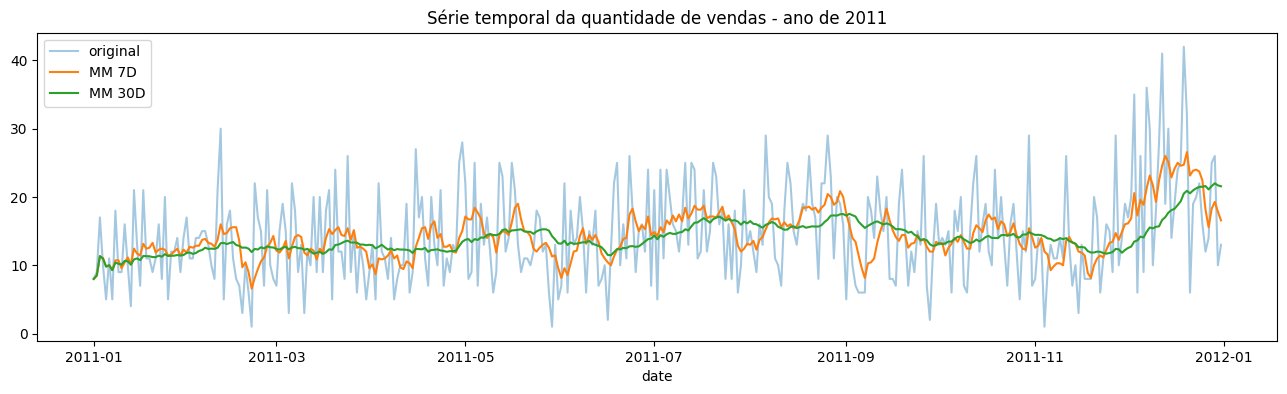

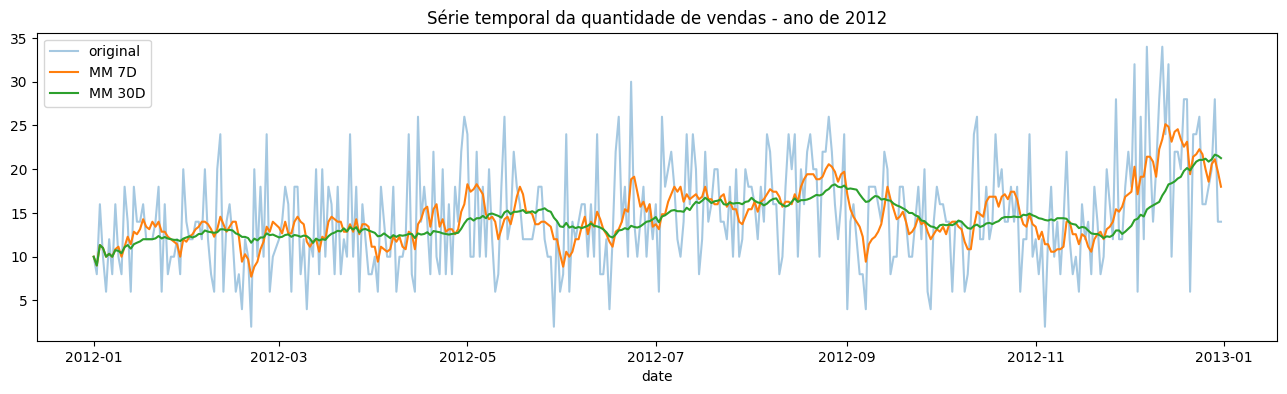

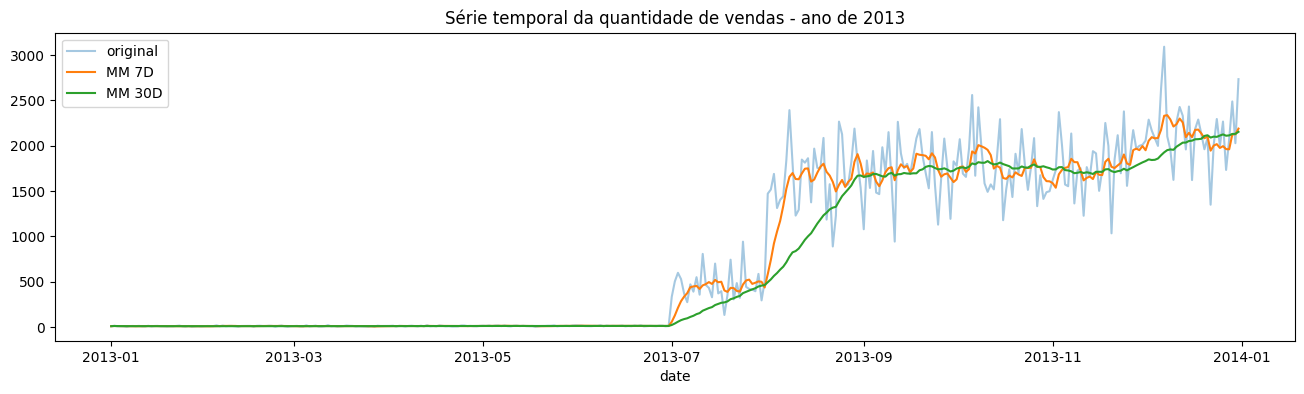

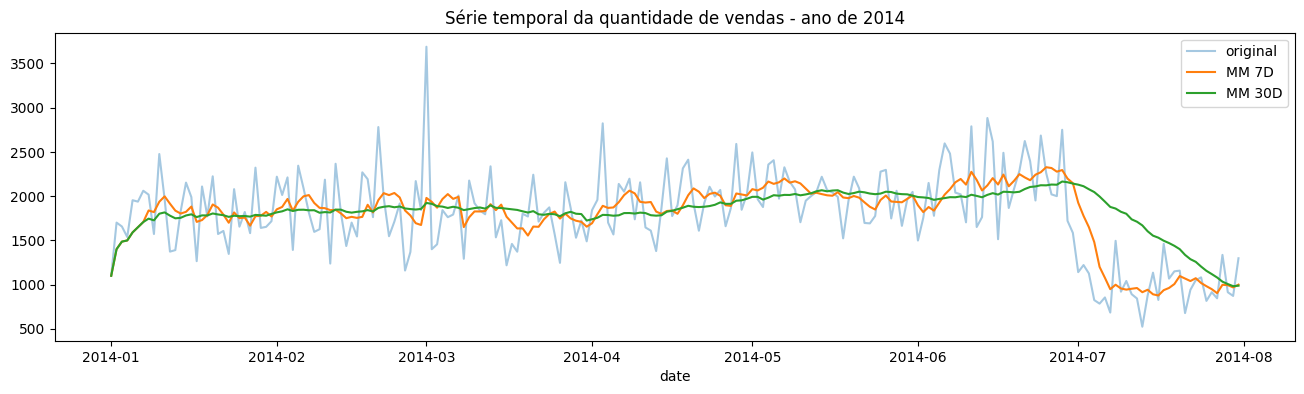

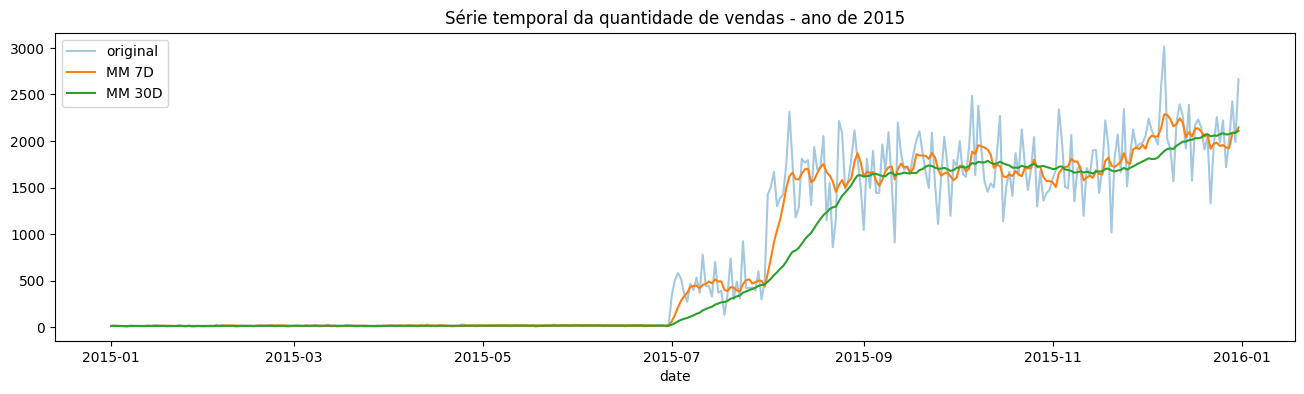

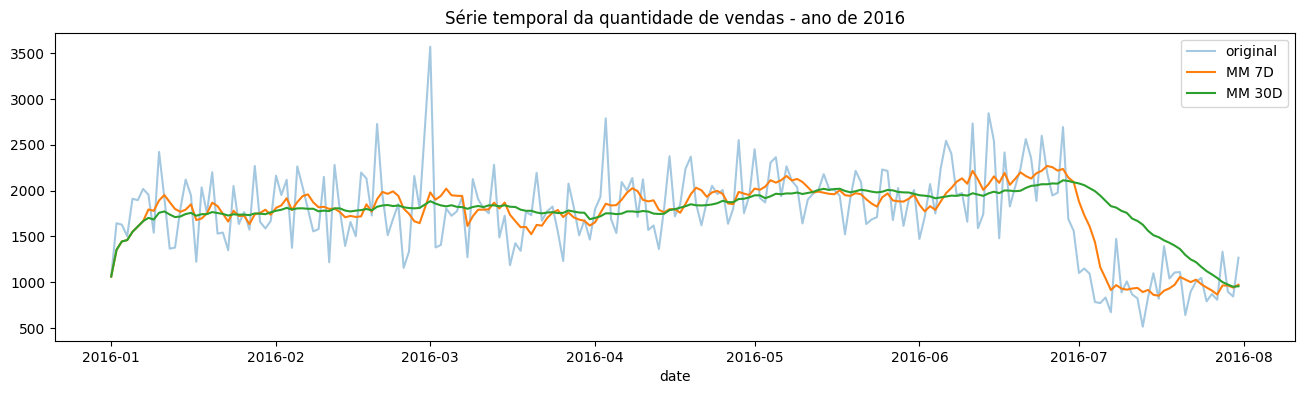

In [11]:
#Plotar somente os periodos necessários
for ano in df["year"].sort_values().unique():
    df_ano = df.query(f"year == {ano}")
    qtdd_total = df_ano.groupby("date")[["order_quantity"]].sum()

    qtdd_total_30d = qtdd_total.rolling(window = "30D").mean()
    qtdd_total_7d = qtdd_total.rolling(window = "7D").mean() #Criar uma janela de 3 dias e ir deslizando ela pelos dados e calculando a media desses valores e colocando dentro de cada celula 

    plt.figure(figsize=(16,4))
    plt.title(f"Série temporal da quantidade de vendas - ano de {ano}")

    sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze(), label = "original", alpha =0.4) #Deixar mais transparente)
    sns.lineplot(x = qtdd_total_7d.index, y = qtdd_total_7d.values.squeeze(), label = "MM 7D")
    sns.lineplot(x = qtdd_total_30d.index, y = qtdd_total_30d.values.squeeze(), label = "MM 30D")

* Olhando para os gráficos 2011 e 2012 são muito parecidos temos um perfil muito claro dessa evolução, não são exatamente igual, percebe-se que em janeiro de 2012 teve um pico de vendas um pouco maior, dado que a média movel de uma semana tá um pouco mais distânciada da media móvel mensal, embora as quantidades exatamente não seja as mesmas tivemos um perfil muito parecido, com a media movel semanal um pouco a cima da mensal. O padrão de como as vendas funcionaram nesses dois anos, é muito parecido ficou estagnado e ao final deu uma leve subida.
* Já em 2013 acontece algo interessante, podemos observar que a partir de julho temos uma subida de vendas considerável, as vendas chegam perto de 3000 nesse período, aconteceu alguam estratégia, alguma mudança, o ideal é conversar com a área de negócio para entender o que aconteceu nesse período. Continua essa tendência de crescimento até setembro, depois ele vai estagnando, mas tem uma leve tendência de alta.
* Quando vamos para 2014 continua alta a taxa de vendas, não em 3000, mas proximo de 2000, teve uma pequena baixa, mas se manteve estável até julho, começou a cair novamente e vai vertiginosamente, os gráficos estavam até 2014 do inicio até o final, mas em 2014 temos dados somente até agosto, depois desse periodo só tem dados até inicio de 2015, temos um buraco na série, ou seja, não temos dados nesse período. Ex: a loja ficou fora do ar, teve algum erro na contabilização, entre outros.
* Em 2015 voltou as vendas lá embaixo, uma hipotese clara é que a loja ficou fora do ar nesse período, em 2015 quando volta já não estava tão quente a loja, levou novamente 6 meses para a tendência de alta parecida com 2013.
* E em 2016 uma tendência bem parecida com 2014 em julho de 2016 ele volta a cair até agosto.

In [12]:
#agrupar os dados pelo mes
df.groupby("month")[["order_quantity"]].sum()

,order_quantity
month,
April,118467
August,103119
December,133312
February,104717
January,110367
July,89787
June,128591
March,111085
May,125715


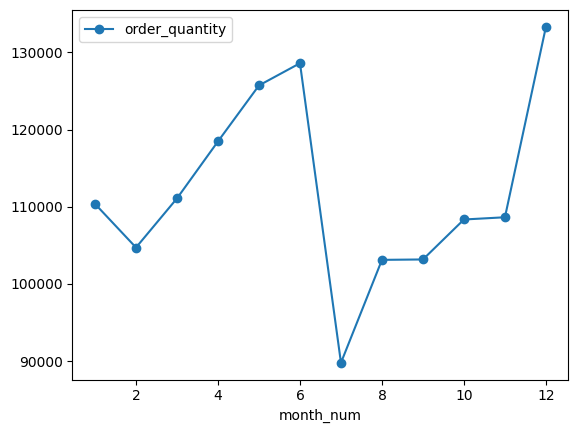

In [13]:
#Colocando os meses em ordem crescente
df["month_num"] = df["date"].apply(lambda x: x.month)
#agrupar os dados pelo mes
df.groupby("month_num")[["order_quantity"]].sum().plot(marker="o")
plt.show()

Quantidade total de vendas - ano de 2011


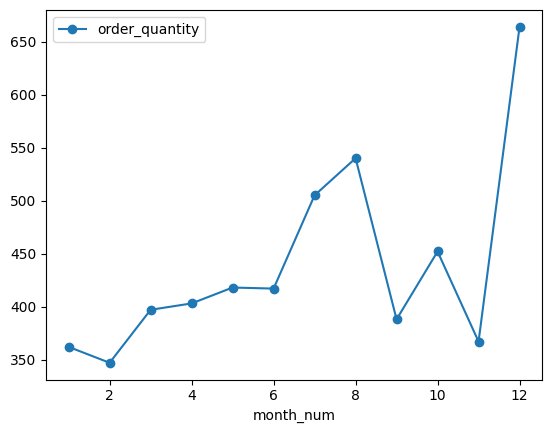

Quantidade total de vendas - ano de 2012


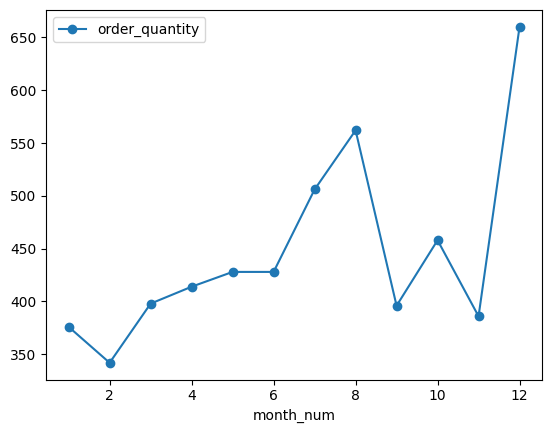

Quantidade total de vendas - ano de 2013


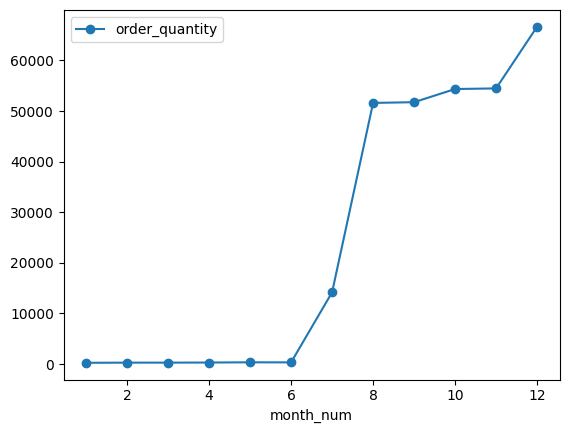

Quantidade total de vendas - ano de 2014


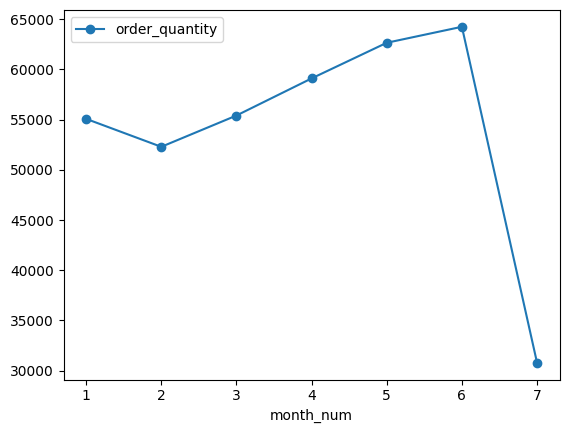

Quantidade total de vendas - ano de 2015


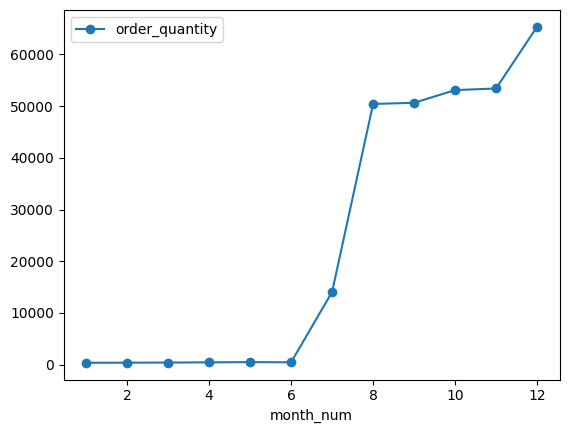

Quantidade total de vendas - ano de 2016


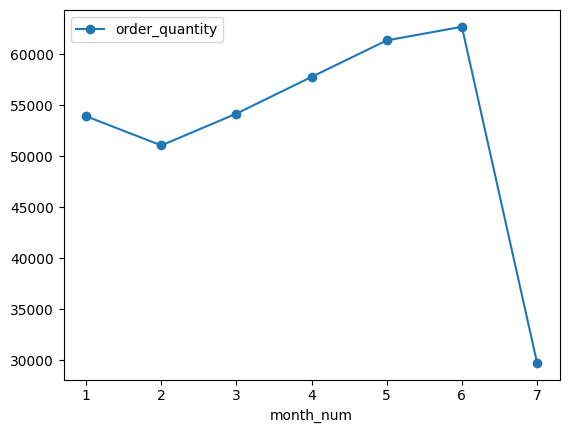

In [14]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Quantidade total de vendas - ano de {ano}")
    df_ano.groupby("month_num")[["order_quantity"]].sum().plot(marker="o")
    plt.show()

## 2 - Qual o perffil dos clientes

In [21]:
df["customer_gender"].describe()

count     113036
unique         2
top            M
freq       58312
Name: customer_gender, dtype: object

In [23]:
df["customer_gender"].value_counts(normalize= True)

customer_gender
M    0.515871
F    0.484129
Name: proportion, dtype: float64

In [24]:
df["age_group"].describe()

count             113036
unique                 4
top       Adults (35-64)
freq               55824
Name: age_group, dtype: object

In [25]:
df["age_group"].value_counts()

age_group
Adults (35-64)          55824
Young Adults (25-34)    38654
Youth (<25)             17828
Seniors (64+)             730
Name: count, dtype: int64

In [17]:
df["customer_age"].describe() #Em média os clientes tem quase 36 anos

count    113036.000000
mean         35.919212
std          11.021936
min          17.000000
25%          28.000000
50%          35.000000
75%          43.000000
max          87.000000
Name: customer_age, dtype: float64

* Em média os clientes tem quase 36 anos
* O mais novo tem 17
* O mais velho tem 87
* É uma distribuição com a media ligeiramente maior que a mediana logo a cauda será mais pronunciada para a direita

<Axes: xlabel='customer_age', ylabel='Count'>

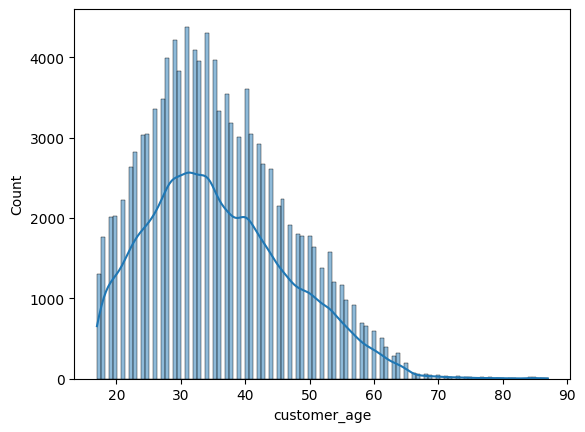

In [18]:
sns.histplot(data = df, x="customer_age", kde = True)

Essa distribuição separada por generos muda?
Essencialmente não altera tanto as distribuições estão muuito coladas uma na outra o que acontece é que nas idades iniciais temos mais homens que mulheres, mas posteriormente eles se equilibram.

<Axes: xlabel='customer_age', ylabel='Count'>

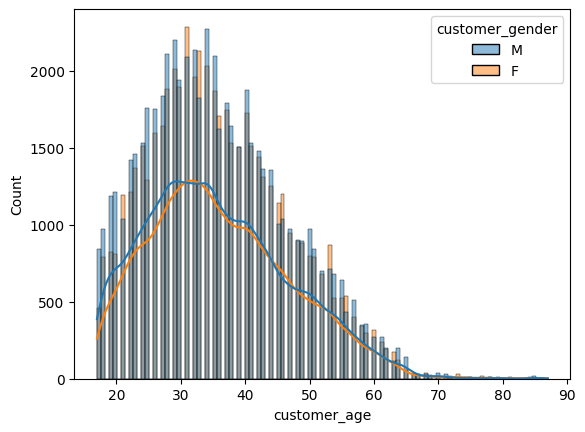

In [26]:
sns.histplot(data = df, x="customer_age", kde = True, hue = "customer_gender")

Fazendo uma análise ano a ano

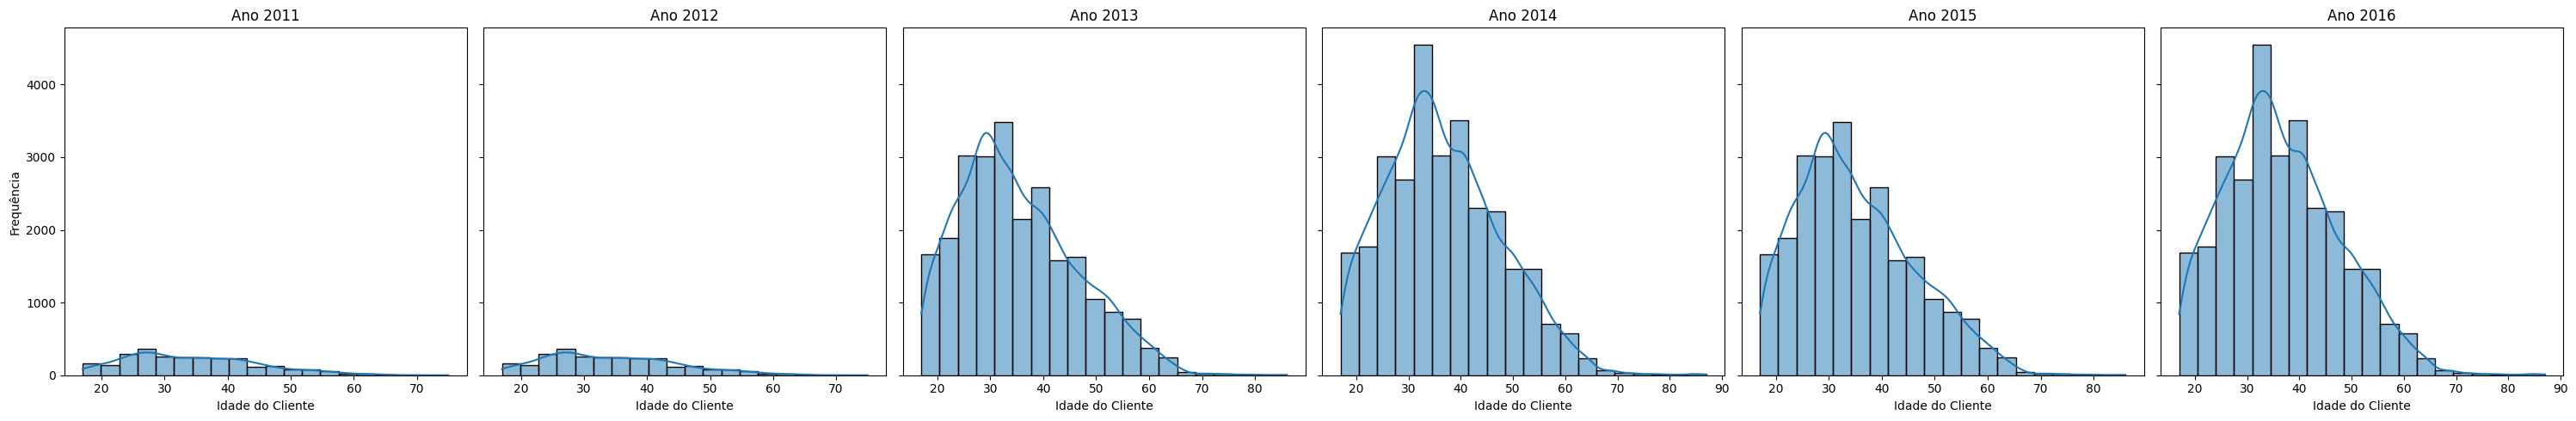

In [28]:
years = sorted(df["year"].unique()) # Lita de anos ordenada
num_year = len(years) # Número total de anos
fig, axes = plt.subplots(1, num_year, figsize = (5 *num_year,5), sharey=True)

# Plotando um histograma para cada ano
for i, year in enumerate(years):
    sns.histplot(df[df["year"] == year]["customer_age"], bins=20, ax=axes[i], kde=True)
    axes[i].set_title(f"Ano {year}")
    axes[i].set_xlabel("Idade do Cliente")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Os histogramas acima representam a distribuição da idade dos clientes ao longo dos anos de **2011 a 2015**. A seguir, destacamos algumas observações importantes:

## **1. Tendência Geral**
- A partir de **2013**, observa-se um aumento significativo no número de clientes, com um formato mais bem definido na distribuição etária.
- Os anos de **2011 e 2012** apresentam uma quantidade menor de clientes, com uma distribuição mais dispersa.

## **2. Faixa Etária Predominante**
- Entre **2013 e 2015**, a maior parte dos clientes se concentra na faixa de **30 a 50 anos**, com um pico por volta dos **35-45 anos**.
- Os dados sugerem que esse grupo representa o público-alvo mais frequente na compra de bicicletas.

## **3. Evolução da Distribuição**
- Em **2013**, a distribuição começa a assumir um padrão claro, com um aumento no número de clientes nas idades centrais.
- Nos anos seguintes (**2014 e 2015**), a distribuição mantém um comportamento semelhante, reforçando a ideia de que a faixa etária entre **30 e 50 anos** continua sendo a mais ativa.

## **4. Considerações Finais**
- O aumento no volume de clientes a partir de **2013** pode indicar um crescimento do mercado ou uma melhora na coleta de dados.
- Os anos iniciais (**2011 e 2012**) podem ter uma baixa representatividade devido a menor quantidade de registros ou início da operação.
- O formato das distribuições sugere que o público-alvo é composto majoritariamente por **adultos de meia-idade**, o que pode ser útil para estratégias de marketing e direcionamento de vendas.

In [31]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Distribuição de gênero - ano de {ano}")
    display(df_ano["customer_gender"].value_counts(normalize=True))
    print(f"\n{'='*80}\n")

Distribuição de gênero - ano de 2011


customer_gender
F    0.513261
M    0.486739
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2012


customer_gender
F    0.513261
M    0.486739
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2013


...

customer_gender
M    0.528301
F    0.471699
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2015


customer_gender
M    0.504112
F    0.495888
Name: proportion, dtype: float64



Distribuição de gênero - ano de 2016


customer_gender
M    0.528301
F    0.471699
Name: proportion, dtype: float64

* O balanço fica bem equilabrado todos os anos, quase 50/50.
* 2011 e 2012 - mais mulhere que homens
* 2012 para frente mais homens
* podendo fazer campanhas especificas para trazer mais clientes mulheres

In [32]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Distribuição de faixa etária - ano de {ano}")
    display(df_ano["age_group"].value_counts(normalize=True))
    print(f"\n{'='*80}\n")

Distribuição de faixa etária - ano de 2011


age_group
Adults (35-64)          0.450878
Young Adults (25-34)    0.363840
Youth (<25)             0.182667
Seniors (64+)           0.002615
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2012


age_group
Adults (35-64)          0.450878
Young Adults (25-34)    0.363840
Youth (<25)             0.182667
Seniors (64+)           0.002615
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2013


...

age_group
Adults (35-64)          0.526192
Young Adults (25-34)    0.325464
Youth (<25)             0.140622
Seniors (64+)           0.007722
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2015


age_group
Adults (35-64)          0.459682
Young Adults (25-34)    0.359408
Youth (<25)             0.175551
Seniors (64+)           0.005359
Name: proportion, dtype: float64



Distribuição de faixa etária - ano de 2016


age_group
Adults (35-64)          0.526192
Young Adults (25-34)    0.325464
Youth (<25)             0.140622
Seniors (64+)           0.007722
Name: proportion, dtype: float64

* A distribuição não ocorreu inversãoes ou seja, sempre mais adultos, depoiis adulto-jovens, jovens e por ultimo senhores.

Como ver a contribuição de cada faixa etária para quantidade de vendas

In [33]:
df.groupby("age_group")[["order_quantity"]].sum()

,order_quantity
age_group,
Adults (35-64),672417
Seniors (64+),9877
Young Adults (25-34),446875
Youth (<25),216147


In [41]:
faixa_etaria_ano = df.groupby("age_group year".split())[["order_quantity"]].sum().reset_index()
faixa_etaria_ano

,age_group,year,order_quantity
0,Adults (35-64),2011,2337
1,Adults (35-64),2012,2414
2,Adults (35-64),2013,136850
3,Adults (35-64),2014,200609
4,Adults (35-64),2015,134073
5,Adults (35-64),2016,196134
6,Seniors (64+),2011,12
7,Seniors (64+),2012,14
8,Seniors (64+),2013,1998
9,Seniors (64+),2014,3004


<Axes: xlabel='year', ylabel='order_quantity'>

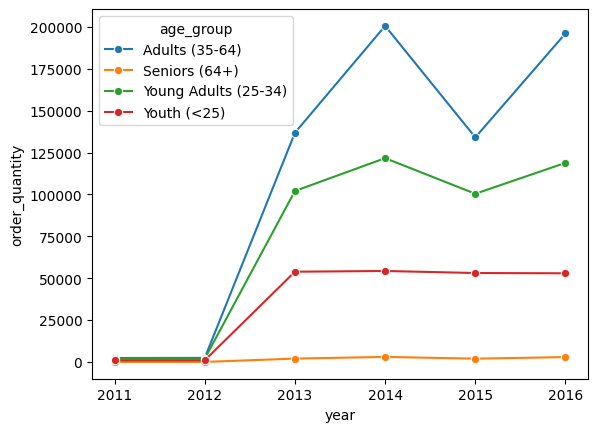

In [42]:
sns.lineplot(data = faixa_etaria_ano, x="year",y="order_quantity", hue="age_group", marker = "o")

<Axes: xlabel='year', ylabel='order_quantity'>

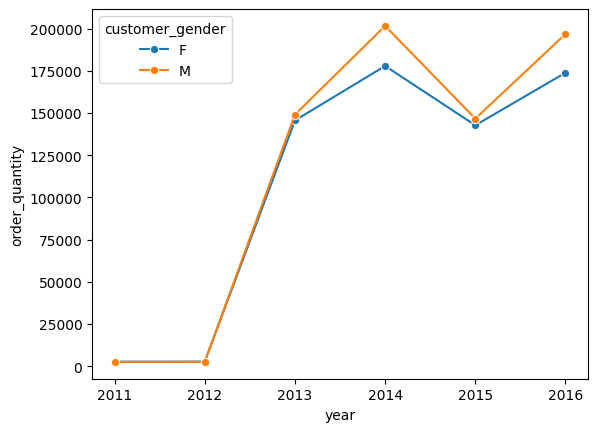

In [45]:
genero_ano = df.groupby("customer_gender year".split())[["order_quantity"]].sum().reset_index()
sns.lineplot(data = genero_ano, x="year",y="order_quantity", hue="customer_gender", marker = "o")

## 3) Analise geográfica
 * Trabalhar com as colunas country e state

In [47]:
df["country"].unique()

array(['Canada', 'Australia', 'United States', 'Germany', 'France',
       'United Kingdom'], dtype=object)

In [48]:
df["state"].nunique() # 53 estados

53

In [49]:
df["state"].unique()

array(['British Columbia', 'New South Wales', 'Victoria', 'Oregon',
       'California', 'Saarland', 'Seine Saint Denis', 'Moselle',
       'Queensland', 'England', 'Nord', 'Washington', 'Hessen',
       'Nordrhein-Westfalen', 'Hamburg', 'Loir et Cher', 'Kentucky',
       'Seine (Paris)', 'South Australia', 'Loiret', 'Alberta', 'Bayern',
       'Hauts de Seine', 'Yveline', 'Essonne', "Val d'Oise", 'Tasmania',
       'Seine et Marne', 'Val de Marne', 'Pas de Calais',
       'Charente-Maritime', 'Garonne (Haute)', 'Brandenburg', 'Texas',
       'New York', 'Florida', 'Somme', 'Illinois', 'South Carolina',
       'North Carolina', 'Georgia', 'Virginia', 'Ohio', 'Ontario',
       'Wyoming', 'Missouri', 'Montana', 'Utah', 'Minnesota',
       'Mississippi', 'Massachusetts', 'Arizona', 'Alabama'], dtype=object)

### proporção de Paises - por aparição na base

In [58]:
df["country"].value_counts(normalize=True)

country
United States     0.346845
Australia         0.211756
Canada            0.125429
United Kingdom    0.120493
Germany           0.098181
France            0.097296
Name: proportion, dtype: float64

<Axes: xlabel='country', ylabel='count'>

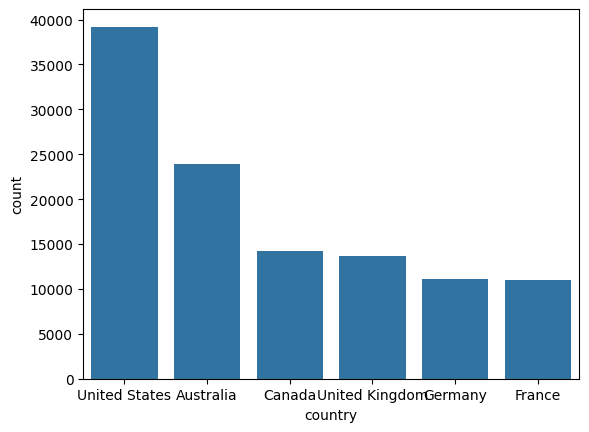

In [57]:
sns.countplot(data = df, x="country",order=df["country"].value_counts(normalize=True).index)

### proporção de Paises - por quantidade vendida

In [62]:
pais_qtdd = df.groupby("country")[["order_quantity"]].sum().reset_index()
pais_qtdd

,country,order_quantity
0,Australia,263585
1,Canada,192259
2,France,128995
3,Germany,125720
4,United Kingdom,157218
5,United States,477539


<Axes: xlabel='country', ylabel='order_quantity'>

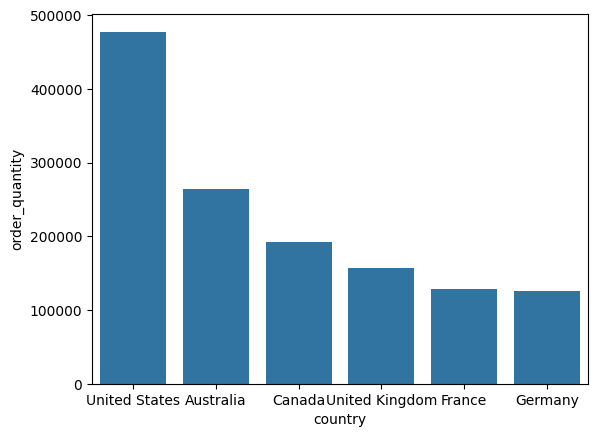

In [64]:
sns.barplot(data=pais_qtdd.sort_values("order_quantity", ascending=False), x="country",y="order_quantity")

Comparando os dois gráficos, o eixo y altera uma pouco a escala, mas matemos algo muito parecido.

In [77]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"quantidade de aparição por país - ano de {ano}")
    display(df_ano["country"].value_counts(normalize=True))
    print(f"\n{'='*80}\n")

quantidade de aparição por país - ano de 2011


country
United States     0.321629
Australia         0.320882
United Kingdom    0.098991
Germany           0.087038
France            0.087038
Canada            0.084423
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2012


country
United States     0.321629
Australia         0.320882
United Kingdom    0.098991
Germany           0.087038
France            0.087038
Canada            0.084423
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2013


...

country
United States     0.348017
Australia         0.196408
Canada            0.128478
United Kingdom    0.121743
Germany           0.104157
France            0.101197
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2015


country
United States     0.348198
Australia         0.218263
Canada            0.126253
United Kingdom    0.121344
France            0.093728
Germany           0.092215
Name: proportion, dtype: float64



quantidade de aparição por país - ano de 2016


country
United States     0.348017
Australia         0.196408
Canada            0.128478
United Kingdom    0.121743
Germany           0.104157
France            0.101197
Name: proportion, dtype: float64

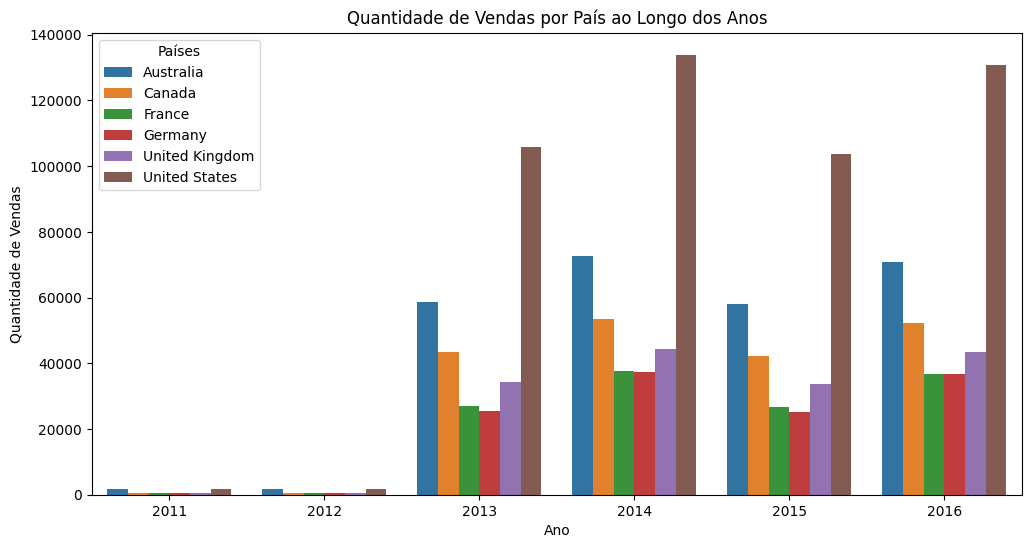

In [78]:
pais_qtdd_ano = df.groupby("country year".split())[["order_quantity"]].sum()
# Criar gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
sns.barplot(data=pais_qtdd_ano, x="year", y="order_quantity", hue="country", palette="tab10")

# Adicionar rótulos e título
plt.xlabel("Ano")
plt.ylabel("Quantidade de Vendas")
plt.title("Quantidade de Vendas por País ao Longo dos Anos")
plt.legend(title="Países")
plt.show()

# **Conclusão**  

A análise da quantidade de pedidos ao longo dos anos revelou padrões distintos entre os países, destacando diferenças significativas no volume de vendas. Observamos que:  

- Os Estados Unidos consistentemente apresentaram o maior número de pedidos, indicando uma forte demanda e presença no mercado.  
- A partir de 2013, houve um crescimento expressivo nas vendas em vários países, sugerindo um período de expansão ou aumento da demanda global.  
- Houve flutuações nos volumes de pedidos em certos países, como Canadá e Reino Unido, possivelmente devido a fatores sazonais ou mudanças econômicas.  

Essa análise fornece insights valiosos sobre tendências de mercado e pode ser utilizada para embasar estratégias de crescimento e otimização da distribuição de produtos. Estudos adicionais poderiam explorar fatores externos, como variações cambiais e políticas comerciais, para entender melhor as causas das mudanças nos volumes de pedidos.  


4. **Quais são os produtos mais vendidos?**
   - Quais categorias e subcategorias de produtos são mais populares?
   - Como a demanda por diferentes produtos varia ao longo do tempo?